# 07 - Interpretability

Two complementary views:

1. **Handcrafted features** (biologically legible). Permutation importance + tree
   importance on the handcrafted/XGBoost model, then a per-class look at *which*
   biochemical features separate *which* classes. This is where the biology lives
   (e.g. hydrophobicity for transporters, charge for nucleic-acid binders).

2. **ESM embeddings** (the actual best model, but abstract). We show why raw
   embedding dimensions don't carry direct biochemical meaning, and instead probe
   the representation a different way — how separable the classes are in embedding
   space. This explains *why* the PLM wins without overclaiming a feature-level
   story it can't support.

## 1. Setup & rebuild the modeling matrices

Reuses the exact alignment + split from NB06 so the models here match the ones we interpreted statistically.

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMB_DIR       = PROJECT_ROOT / "data" / "embeddings"
RESULTS_DIR   = PROJECT_ROOT / "results"
SRC_DIR       = PROJECT_ROOT / "src"
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

In [3]:

sys.path.insert(0, str(SRC_DIR))
from embeddings import load_embeddings
import features as F
import train as T

In [4]:
CLASS_ORDER  = ["enzyme", "dna_rna_binding", "receptor", "transporter", "structural", "other"]
RANDOM_STATE = T.RANDOM_STATE
FEATURE_COLS = F.feature_columns()

In [5]:
# Load + align (identical logic to NB06)
feats = pd.read_csv(PROCESSED_DIR / "sequence_features.csv", index_col="accession")
feats.index = feats.index.astype(str)
emb, emb_meta = load_embeddings(EMB_DIR)
emb_df = pd.DataFrame(emb, index=emb_meta["accession"].astype(str))
emb_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
accession,,,,,,,,,,,,,,,,,,,,,
A0A1B0GTW7,0.032431,-0.109507,0.023434,0.068303,0.009747,-0.017370,0.017636,0.102932,0.039798,0.185818,...,-0.038912,0.071501,-0.165677,0.018231,-0.060598,-0.036803,0.051956,-0.106041,-0.033914,-0.030717
A0JP26,-0.005885,-0.064460,0.015845,0.012239,-0.007035,-0.101205,0.046978,0.036566,-0.018538,-0.011754,...,0.010463,0.038635,-0.119247,-0.019228,-0.001546,0.029916,0.027882,-0.032380,-0.006830,-0.042010
A0PK11,-0.072630,0.047562,-0.028570,-0.054891,0.006429,0.005932,0.103211,0.006289,0.018597,0.006285,...,0.084446,-0.018361,-0.061610,-0.022082,-0.001344,0.077126,0.067155,0.006176,-0.079037,0.067796
A1A4S6,0.040821,-0.078198,-0.088786,0.059718,-0.258805,-0.065447,0.134315,-0.076152,-0.069878,0.144815,...,-0.020157,-0.092655,-0.107863,0.028733,0.031444,-0.067961,-0.007925,-0.191179,0.048702,0.105249
A1A519,0.044102,-0.006909,0.043508,0.078491,-0.050447,-0.062629,0.032953,0.141595,0.048454,0.066511,...,0.054796,0.083212,-0.208749,-0.024244,-0.016349,-0.028425,-0.040720,-0.021586,0.050093,-0.006970


In [6]:
src_df = pd.read_csv(PROCESSED_DIR / "labeled_dataset.csv")
keep_acc = src_df.drop_duplicates(subset="sequence", keep="first")["accession"].astype(str)
feats = feats.loc[feats.index.intersection(keep_acc)]
order = list(feats.index.intersection(emb_df.index))
feats.head()

,function_class,seq_length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy,frac_hydrophobic,frac_polar_uncharged,frac_positive,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
accession,,,,,,,,,,,,,,,,,,,,,
A0A1B0GTW7,enzyme,788,85395.9714,0.065990,41.752284,8.038192,-0.141624,0.380711,0.393401,0.121827,...,0.016497,0.017766,0.077411,0.050761,0.050761,0.096447,0.060914,0.053299,0.016497,0.025381
A0JP26,other,581,65709.6952,0.041308,48.240448,6.239750,-0.775387,0.333907,0.314974,0.177281,...,0.030981,0.060241,0.027539,0.051635,0.049914,0.080895,0.037866,0.046472,0.008606,0.017212
A0PK11,transporter,232,25445.8398,0.112069,31.439655,6.508372,0.757759,0.556034,0.254310,0.090517,...,0.017241,0.025862,0.030172,0.038793,0.025862,0.056034,0.030172,0.107759,0.021552,0.025862
A1A4S6,structural,786,89373.5585,0.083969,50.047226,6.751472,-0.585623,0.346056,0.334606,0.160305,...,0.022901,0.044529,0.063613,0.043257,0.055980,0.080153,0.053435,0.052163,0.008906,0.021628
A1A519,dna_rna_binding,330,37157.5659,0.045455,74.251212,4.997989,-1.018485,0.260606,0.400000,0.145455,...,0.033333,0.027273,0.054545,0.063636,0.063636,0.121212,0.066667,0.066667,0.012121,0.015152


In [7]:
y      = feats.loc[order, "function_class"].to_numpy()
X_hand = feats.loc[order, FEATURE_COLS]          # keep as DataFrame for named importances
X_emb  = emb_df.loc[order].to_numpy()

In [8]:
X_hand.shape, X_emb.shape, y.shape

((8513, 32), (8513, 1280), (8513,))

In [9]:
from sklearn.model_selection import train_test_split
idx = np.arange(len(order))
train_idx, test_idx = train_test_split(idx, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
y_train, y_test = y[train_idx], y[test_idx]
print(f"Aligned {len(order)} proteins | handcrafted {X_hand.shape[1]} | emb {X_emb.shape[1]}")


Aligned 8513 proteins | handcrafted 32 | emb 1280


---
# Part 1 - Handcrafted feature interpretation

## 2. Fit the handcrafted/XGBoost model

In [10]:
le = LabelEncoder().fit(CLASS_ORDER)

hand_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, tree_method="hist",
    objective="multi:softprob", num_class=len(CLASS_ORDER),
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
)
hand_model.fit(X_hand.iloc[train_idx], le.transform(y_train))
print("Fitted handcrafted/XGBoost.")


Fitted handcrafted/XGBoost.


## 3. Permutation importance (model-agnostic, the trustworthy one)

Permutation importance measures how much test macro-F1 *drops* when a feature's
values are shuffled. Unlike XGBoost's built-in importance (which can be biased
toward high-cardinality features), this directly answers "how much does the model
*rely* on this feature?" Computed on the test set.

In [11]:
macro_f1 = make_scorer(f1_score, average="macro")
perm = permutation_importance(
    hand_model, X_hand.iloc[test_idx], le.transform(y_test),
    scoring=macro_f1, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_df = (pd.DataFrame({"feature": FEATURE_COLS,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False)
           .reset_index(drop=True))
perm_df.head(15)

,feature,importance,std
0,aa_C,0.032586,0.005222
1,gravy,0.027722,0.006228
2,aa_G,0.026064,0.005660
3,aa_W,0.022018,0.006748
4,seq_length,0.020391,0.003246
5,frac_positive,0.016957,0.003110
6,aa_S,0.014517,0.006336
7,aa_I,0.014139,0.004701
8,aa_L,0.012481,0.004262
9,frac_negative,0.009946,0.002095


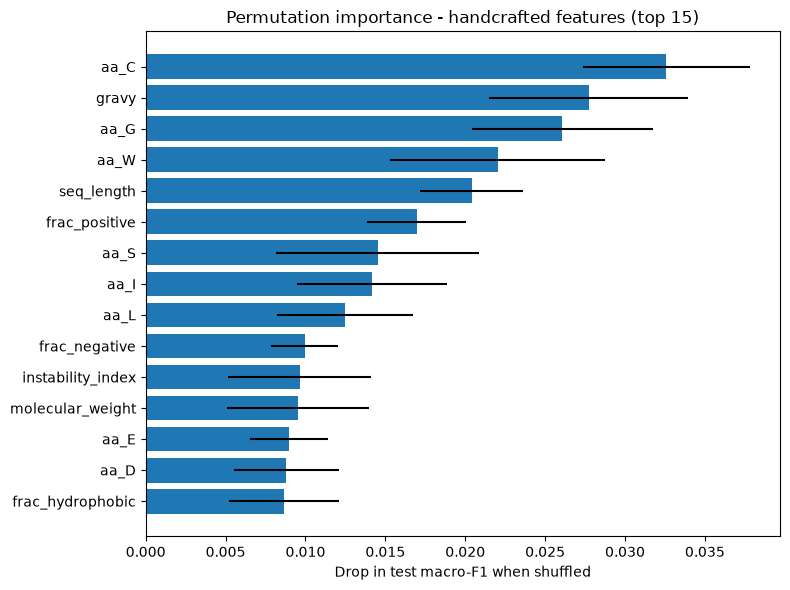

In [12]:
top = perm_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["importance"], xerr=top["std"])
ax.set_xlabel("Drop in test macro-F1 when shuffled")
ax.set_title("Permutation importance - handcrafted features (top 15)")
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation
The most striking feature of this ranking is how **flat** it is. 
- The top feature (`aa_C`) drops test macro-F1 by only ~0.04 when shuffled, and importance decays gently from there with no clear breakpoint — no single feature dominates. This is consistent with the handcrafted model's modest 0.527 ceiling: its performance is spread thinly across many weakly-informative features rather than resting on a few strong ones, which is exactly why the richer ESM representation outperformed it so decisively.
- Several features that surface here are biochemically sensible. `aa_C` (cysteine) leading is plausible — cysteine forms disulfide bonds and is unevenly distributed across protein types, giving it real discriminative signal. `aa_G` (glycine) follows, consistent with its enrichment in structural proteins. The hydrophobicity features (`gravy`, `frac_hydrophobic`) and charge features (`frac_positive`, `frac_negative`) — the ones expected to flag transporters and nucleic-acid binders respectively — appear as meaningful but mid-pack contributors. 
- `seq_length` and `molecular_weight` rank but do not lead, confirming the initial EDA finding that length is a weak standalone separator.

**Caveat**: this ranking shows which features the model relies on _overall_, not which class each feature serves. A feature like `gravy` could do all its work separating one class and nothing else — this aggregate view cannot reveal that. The per-class signatures below are where the directional biology ("hydrophobicity → transporters, charge → nucleic-acid binders") is actually confirmed or denied; this table only identifies which features are worth examining there.

## 4a. Per-class biochemical signatures

Importance tells us *which* features matter overall; this tells us *how* they
differ *by class*. We standardize each feature, then show each class's mean
(z-score) — so a value of +1 means "this class sits one SD above average on this
feature." This is where the biological story comes from.

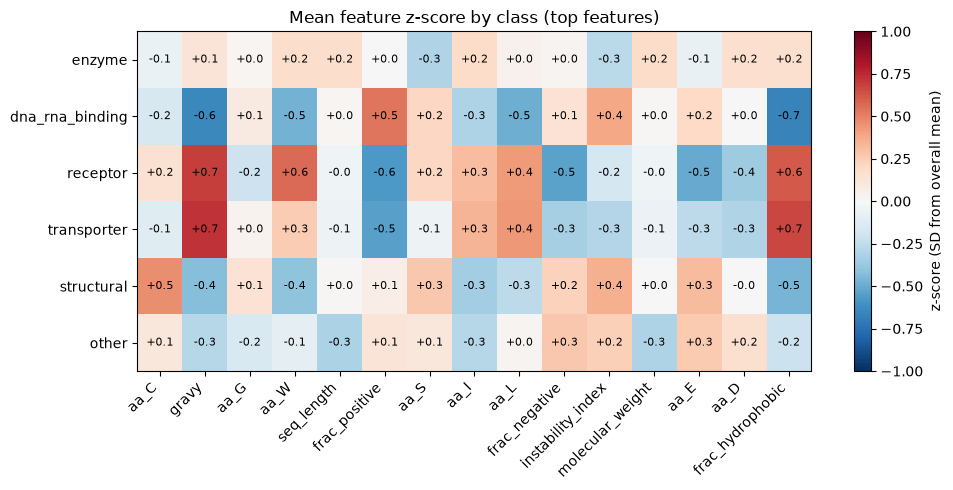

In [13]:
# Focus on the most important features for readability.
focus = perm_df.head(15)["feature"].tolist()
Z = pd.DataFrame(StandardScaler().fit_transform(X_hand[focus]), columns=focus, index=order)
Z["class"] = y
class_means = Z.groupby("class")[focus].mean().reindex(CLASS_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(class_means.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(focus))); ax.set_xticklabels(focus, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_ORDER))); ax.set_yticklabels(CLASS_ORDER)
ax.set_title("Mean feature z-score by class (top features)")
fig.colorbar(im, ax=ax, label="z-score (SD from overall mean)")
for i in range(len(CLASS_ORDER)):
    for j in range(len(focus)):
        ax.text(j, i, f"{class_means.values[i,j]:+.1f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "class_feature_signatures.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation

_The heatmap confirms the predicted feature→class associations._

- **Hydrophobicity** (`gravy`, `frac_hydrophobic`) **is the clearest signal**. **Transporters** (+0.7) and **Receptors** (+0.6/+0.7) score strongly positive, consistent with membrane-spanning regions, while DNA/RNA-binding proteins score strongly negative (−0.6/−0.7), consistent with their soluble nuclear localization. 
- **Positive charge** (`frac_positive`). DNA/RNA-binding proteins are the one class clearly elevated (+0.5), consistent with binding the negatively-charged nucleic-acid backbone, while the membrane classes sit negative.
- **Cysteine** (`aa_C`). Highest in structural proteins (+0.5), consistent with disulfide-bond stabilization — and the reason it led the permutation-importance ranking.
- **Receptor ≈ transporter**. Both share a hydrophobic, low-charge profile, consistent with their shared membrane biology and a likely source of confusion between them.
- **Length features** (`molecular_weight`, `seq_length`) — near-zero everywhere. Confirms length is a weak standalone separator.
- **enzyme and other rows** — largely flat. Consistent with enzymes being defined by catalytic annotation rather than bulk composition, and other being a heterogeneous catch-all without a coherent signature. This ties back to these being harder classes in the confusion matrix.

**Caveat**: _all associations are correlational — the labels derive from annotations, so these reflect what the model learned, not independent mechanistic proof._


## 4b. SHAP - directional, per-protein explanations (handcrafted model)

Permutation importance gave *magnitude* ("scrambling gravy costs 0.03") but no *direction*. SHAP assigns every feature a **signed** contribution per prediction, so we can finally say "high hydrophobicity pushes *toward* transporter" and explain individual proteins. We use `TreeExplainer` (exact + fast for XGBoost).

In [14]:
import shap

# TreeExplainer is exact and fast for tree models. We explain the TEST set.
X_test_hand = X_hand.iloc[test_idx]
explainer = shap.TreeExplainer(hand_model)
shap_values = explainer.shap_values(X_test_hand)

# For multiclass XGBoost, shap_values is shape (n_samples, n_features, n_classes)
# (newer shap) or a list of per-class arrays (older shap). Normalize to a list.
import numpy as np
if isinstance(shap_values, list):
    sv_by_class = shap_values                      # older API: list of arrays
else:
    sv_by_class = [shap_values[:, :, k] for k in range(shap_values.shape[2])]

print(f"SHAP computed for {len(sv_by_class)} classes, "
      f"{X_test_hand.shape[0]} test proteins, {X_test_hand.shape[1]} features.")
print("Class order:", list(le.classes_))

SHAP computed for 6 classes, 1703 test proteins, 32 features.
Class order: [np.str_('dna_rna_binding'), np.str_('enzyme'), np.str_('other'), np.str_('receptor'), np.str_('structural'), np.str_('transporter')]


### Global directional view (beeswarm) for one class

A beeswarm shows, for every test protein, how each feature pushed the prediction toward or away from a chosen class. Each dot is a protein; colour is the feature value (red = high, blue = low); x-position is the SHAP contribution. 

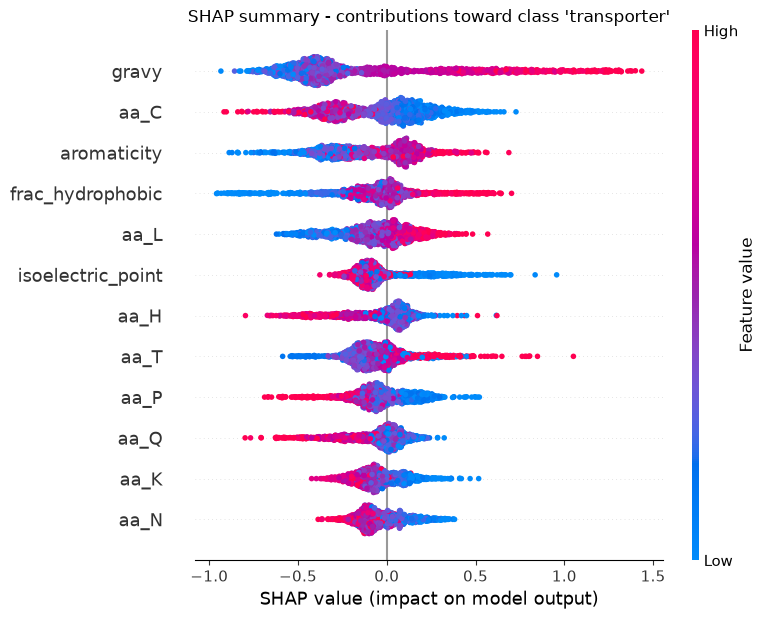

In [15]:
# For Transporter class
cls_name = "transporter"
k = list(le.classes_).index(cls_name)

shap.summary_plot(
    sv_by_class[k], X_test_hand,
    plot_type="dot", max_display=12, show=False,
)

plt.title(f"SHAP summary - contributions toward class '{cls_name}'")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / f"shap_summary_{cls_name}.png", dpi=150, bbox_inches="tight")
plt.show()

**SHAP Reading**:
- `gravy`: red dots stretch far to the right, blue dots cluster left. High hydrophobicity → strongly pushes toward transporter. Exactly the membrane-protein prediction, now with direction confirmed.
- `frac_hydrophobic`: same pattern — red right, blue left. Reinforces the same biology.
- `isoelectric_point`: the colors flip — blue (low pI) on the right, red (high pI) on the left. Low isoelectric point pushes toward transporter. It's the inverse of the basic, positively-charged profile that characterizes nucleic-acid binders, which makes sense.

_So transporter is driven positively by hydrophobicity and away by basic charge — a coherent membrane signature._

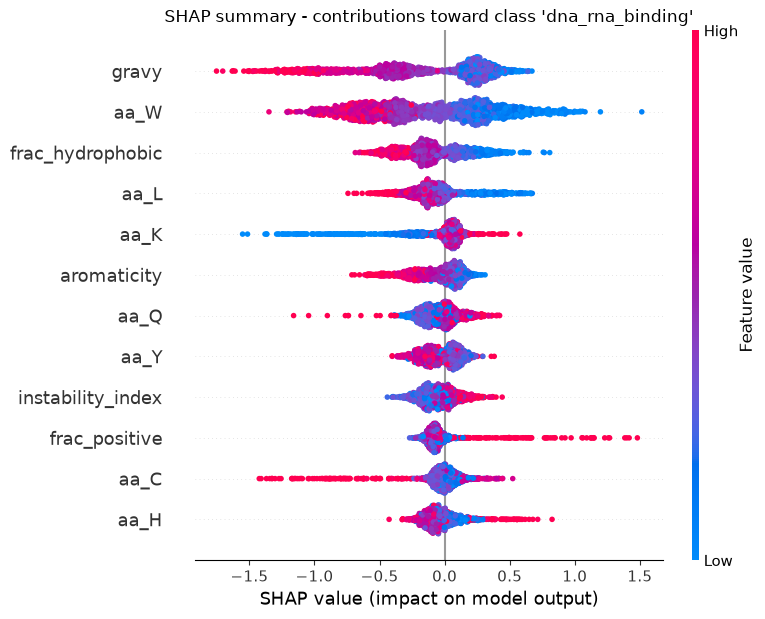

In [16]:
# For DNA/RNA binding class
cls_name = "dna_rna_binding"
k = list(le.classes_).index(cls_name)

shap.summary_plot(
    sv_by_class[k], X_test_hand,
    plot_type="dot", max_display=12, show=False,
)

plt.title(f"SHAP summary - contributions toward class '{cls_name}'")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / f"shap_summary_{cls_name}.png", dpi=150, bbox_inches="tight")
plt.show()

**SHAP Reading**
- `gravy` and `frac_hydrophobic`: Here red dots sit on the left — high hydrophobicity pushes away from this class. Opposite of transporter, which is right: these are soluble, not membrane, proteins.
-  `frac_positive`: red dots on the right — high positive charge pushes toward DNA/RNA-binding. The charge prediction, confirmed directionally — positively charged proteins binding the negative nucleic-acid backbone.
- `aa_K` (lysine, a positively-charged residue) shows red pushing right too, which is the same charge story at the individual-residue level — a nice corroboration.

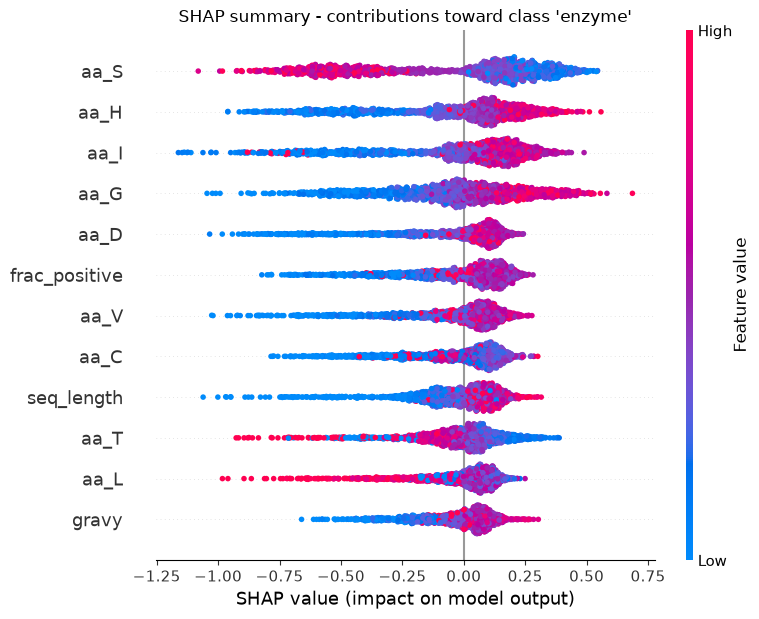

In [17]:
# For enzyme class
cls_name = "enzyme"
k = list(le.classes_).index(cls_name)

shap.summary_plot(
    sv_by_class[k], X_test_hand,
    plot_type="dot", max_display=12, show=False,
)

plt.title(f"SHAP summary - contributions toward class '{cls_name}'")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / f"shap_summary_{cls_name}.png", dpi=150, bbox_inches="tight")
plt.show()

**SHAP Reading**

_For Enzyme we find real but asymmetric, exclusionary signal._

This class is defined more by what it lacks than a positive fingerprint:
- The positive side is weak (few features push strongly toward enzyme), but the negative side is well-developed — low values of `aa_H`, `aa_I`, `aa_D`, `aa_V` consistently push toward enzyme, while their presence pushes away.
- `aa_S` (top-ranked for this class) shows high serine clustering on the negative side: serine-rich regions argue against the enzyme call, likely because they mark structural/low-complexity or binding proteins.

Thus enzymes are compositionally defined in the negative — identified by the absence of residues that characterize other classes rather than a shared positive trait. This fits enzymes being a large, heterogeneous group unified by catalytic annotation, not a common biochemical signature.

### Local view - explain TWO individual proteins

A force/waterfall plot explains a single protein's prediction: which features pushed it toward its predicted class and by how much. We pick two proteins the model classified **confidently and correctly**, so the explanation is clean.


Protein P62899: predicted dna_rna_binding (confidence 1.00)


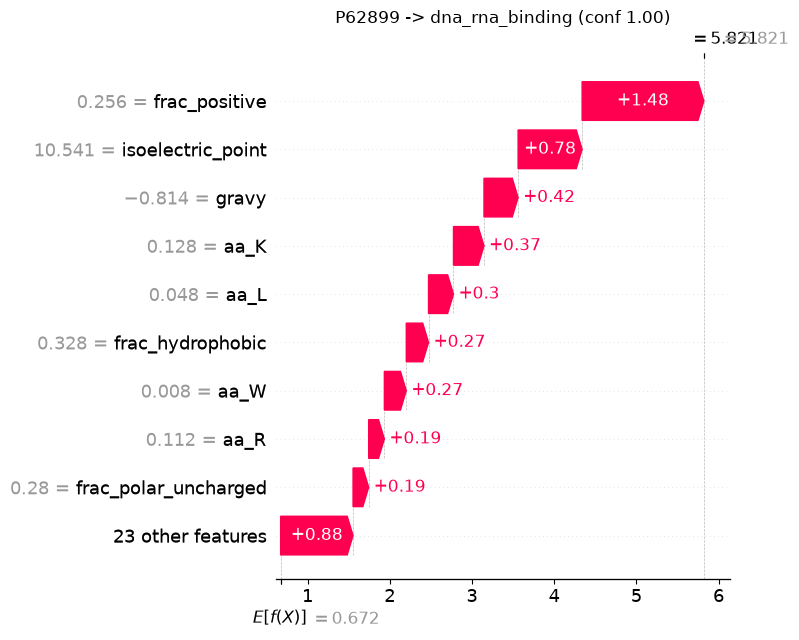


Protein P60370: predicted structural (confidence 1.00)


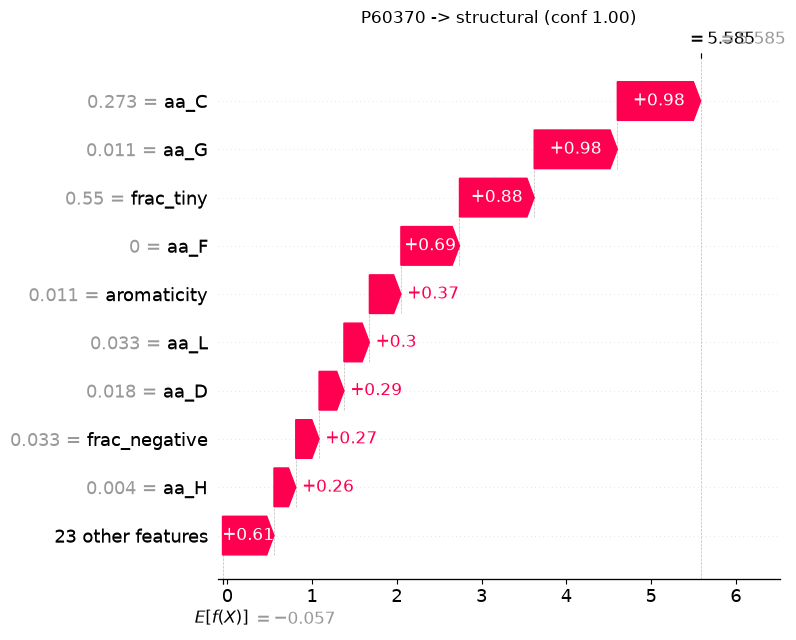

In [18]:
# Confident, correct test predictions to use as clean examples.
proba = hand_model.predict_proba(X_test_hand)
pred_int = proba.argmax(1)
true_int = le.transform(y_test)
conf = proba.max(1)

good = np.where((pred_int == true_int) & (conf > 0.7))[0]
# Pick two from different classes if possible.
picks = []
seen = set()
for i in good[np.argsort(conf[good])[::-1]]:
    c = pred_int[i]
    if c not in seen:
        picks.append(i); seen.add(c)
    if len(picks) == 2:
        break

for i in picks:
    cls = le.classes_[pred_int[i]]
    acc = X_test_hand.index[i]
    print(f"\nProtein {acc}: predicted {cls} (confidence {conf[i]:.2f})")
    shap.waterfall_plot(
        shap.Explanation(
            values=sv_by_class[pred_int[i]][i],
            base_values=explainer.expected_value[pred_int[i]],
            data=X_test_hand.iloc[i],
            feature_names=list(X_test_hand.columns),
        ),
        max_display=10, show=False,
    )
    import matplotlib.pyplot as plt
    plt.title(f"{acc} -> {cls} (conf {conf[i]:.2f})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "figures" / f"shap_waterfall_{acc}.png", dpi=150, bbox_inches="tight")
    plt.show()

---
# Part 2 - ESM embedding interpretation

## 5. Why raw embedding dimensions resist a biological story

We *can* run permutation importance on the 1280 embedding dims, but a result like
"dimension 847 matters most" has no biochemical meaning — ESM dimensions are
learned, distributed, and entangled, not aligned to named properties. Showing this
briefly is more honest than pretending otherwise. We compute it, then make exactly
that point with the plot.

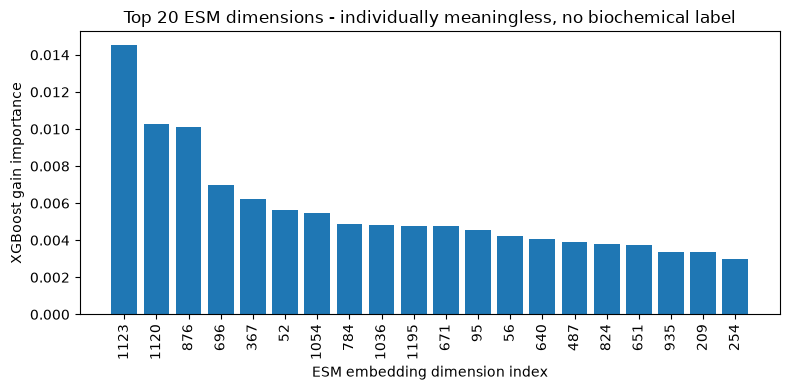

No single dimension dominates; importance is spread across many dims -
the signal is distributed, which is exactly why ESM resists feature-level
biological interpretation but still outperforms handcrafted features.


In [19]:
# Fit ESM/XGBoost (the actual best model) and get its top dims, to illustrate.
esm_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, tree_method="hist",
    objective="multi:softprob", num_class=len(CLASS_ORDER),
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
)
esm_model.fit(X_emb[train_idx], le.transform(y_train))

imp = esm_model.feature_importances_
top_dims = np.argsort(imp)[::-1][:20]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(d) for d in top_dims], imp[top_dims])
ax.set_xlabel("ESM embedding dimension index")
ax.set_ylabel("XGBoost gain importance")
ax.set_title("Top 20 ESM dimensions - individually meaningless, no biochemical label")
plt.xticks(rotation=90); plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "esm_dim_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("No single dimension dominates; importance is spread across many dims -")
print("the signal is distributed, which is exactly why ESM resists feature-level")
print("biological interpretation but still outperforms handcrafted features.")


## 6. A better probe: class structure in embedding space

Instead of asking "what does dim N mean?", ask "does the embedding *organize*
proteins by function?" We project the 1280-dim embeddings to 2D with PCA and color
by class. Clean clustering visually explains the model's accuracy — the
representation already groups functional classes before any classifier touches it.

### 6a. PCA

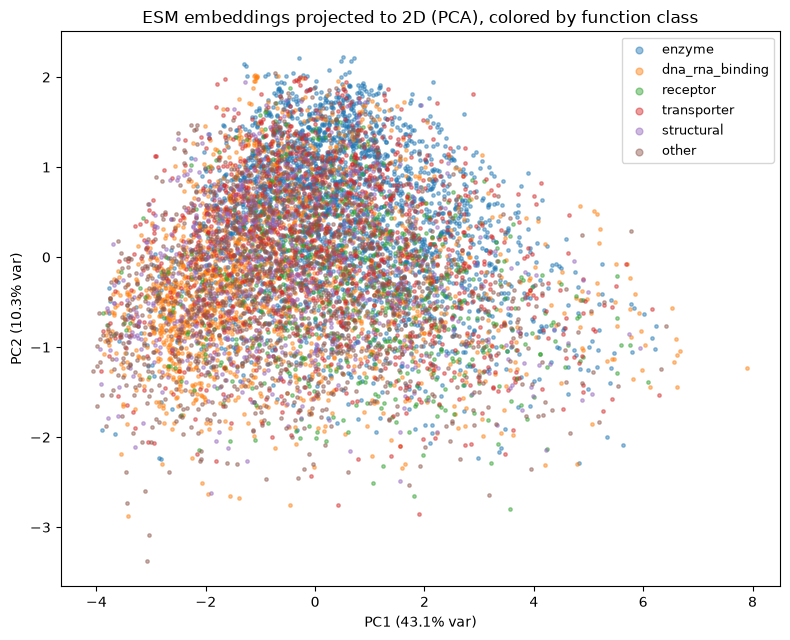

PC1+PC2 explain 53.3% of variance.


In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(X_emb)

fig, ax = plt.subplots(figsize=(8, 6.5))
for cls in CLASS_ORDER:
    m = (y == cls)
    ax.scatter(P[m, 0], P[m, 1], s=6, alpha=0.45, label=cls)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("ESM embeddings projected to 2D (PCA), colored by function class")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "esm_pca_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"PC1+PC2 explain {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of variance.")


### 6b. UMAP - a non-linear 2D view

The PCA plot above is a blob because PCA is **linear**: it can only find straight-line axes of variance, and the top two capture just ~53% of the embedding's structure. The class separation that the classifier exploits is spread across many dimensions PCA can't show in 2D.

UMAP is **non-linear** - it preserves *local neighbourhood* structure when collapsing to 2D, so it can reveal clusters that PCA smears together. If the embeddings really do organize proteins by function (and the 0.717 macro-F1 says they do), UMAP should make that visible.

In [22]:
import umap   # from the umap-learn package

reducer = umap.UMAP(
    n_neighbors=15,        # balances local vs global structure; 15 is a good default
    min_dist=0.1,          # how tightly points pack within a cluster
    metric="cosine",       # cosine works well for transformer embeddings
    random_state=RANDOM_STATE,
)
U = reducer.fit_transform(X_emb)   # (n_proteins, 2); may take ~1-2 min

c:\Users\sridi\anaconda3\envs\protein-func\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


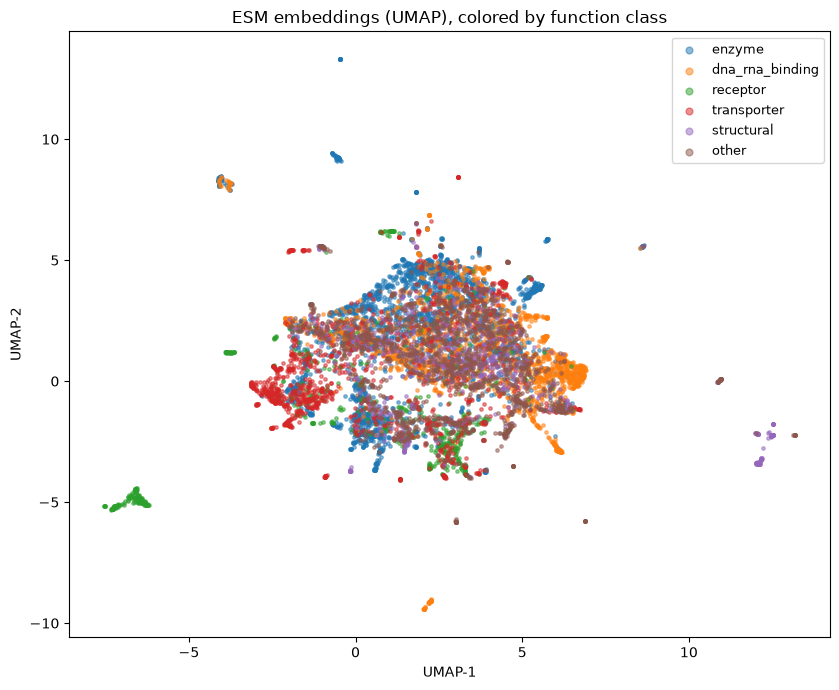

In [24]:
fig, ax = plt.subplots(figsize=(8.5, 7))
for cls in CLASS_ORDER:
    m = (y == cls)
    ax.scatter(U[m, 0], U[m, 1], s=6, alpha=0.5, label=cls)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("ESM embeddings (UMAP), colored by function class")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "esm_umap_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. t-SNE

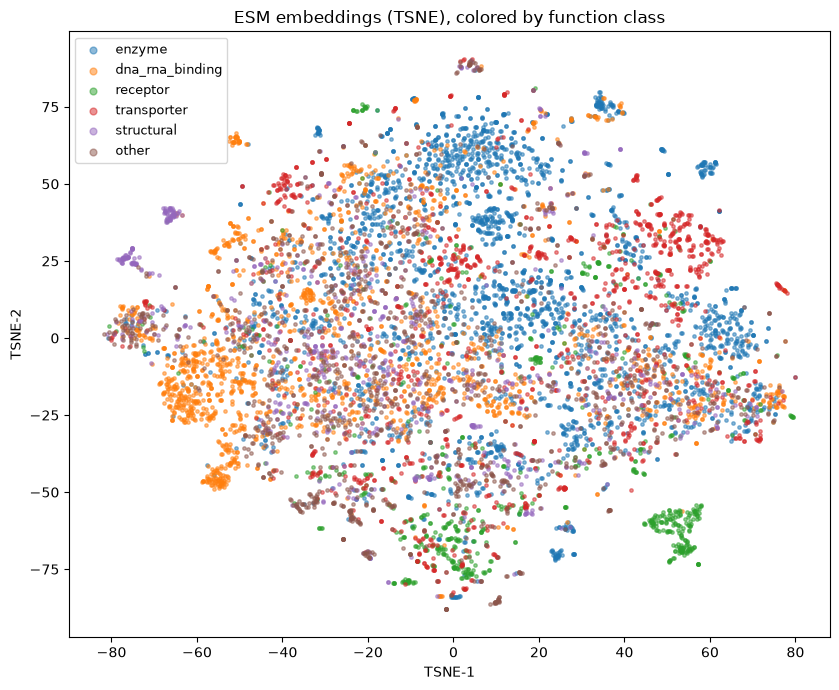

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, metric="cosine", init="pca",
            perplexity=30, random_state=RANDOM_STATE)
U = tsne.fit_transform(X_emb)   # slower than UMAP, ~2-4 min on your data

fig, ax = plt.subplots(figsize=(8.5, 7))
for cls in CLASS_ORDER:
    m = (y == cls)
    ax.scatter(U[m, 0], U[m, 1], s=6, alpha=0.5, label=cls)
ax.set_xlabel("TSNE-1")
ax.set_ylabel("TSNE-2")
ax.set_title("ESM embeddings (TSNE), colored by function class")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "esm_tsne_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Interpretation

